# Fine-Tuning Pre-trained Transformer Models
## COM3029 NLP Group Coursework



## Cell 1  Install Dependencies


In [28]:
# Install required packages
!pip install transformers datasets scikit-learn evaluate seqeval accelerate -q


## Cell 2 Imports and Seed Setup

In [29]:
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

# Two seed values used for two runs each
SEEDS = [42, 1234]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

print("Imports complete.")

Device: cuda
PyTorch version: 2.10.0+cu128
Imports complete.



## Cell 3  Load Dataset
BESSTIE dataset from HuggingFace.

In [30]:
ds = load_dataset("surrey-nlp/BESSTIE-CW-26")

train_df = ds["train"].to_pandas()
val_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()

train_df["Sentiment"] = train_df["Sentiment"].astype(int)
val_df["Sentiment"] = val_df["Sentiment"].astype(int)
test_df["Sentiment"] = test_df["Sentiment"].astype(int)

print(ds)
print(f"\nTrain size:      {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size:       {len(test_df)}")
print("\nFirst few rows from training set:")
print(train_df[["text", "variety", "Sentiment", "Sarcasm"]].head(3))

DatasetDict({
    train: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 3747
    })
    validation: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 313
    })
    test: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 2183
    })
})

Train size:      3747
Validation size: 313
Test size:       2183

First few rows from training set:
                                                text variety  Sentiment  \
0  I'm a member of the Green Party but I'll be vo...   en-UK          0   
1  Yeah it blew out to 3x what it was budgeted fo...   en-AU          0   
2  Food was pretty great. A little dry, but I am ...   en-AU          1   

   Sarcasm  
0      0.0  
1      1.0  
2      0.0  



## Cell 4  Tokenisation Helper
This function converts a pandas DataFrame into a HuggingFace Dataset and tokenises it.
It is reused for both RoBERTa and XLM-RoBERTa experiments.

In [31]:
from datasets import Dataset as HFDataset

def make_hf_dataset(df, tokenizer, task="Sentiment", max_length=128):
    hf_ds = HFDataset.from_pandas(
        df[["text", task]].rename(columns={task: "labels"})
    )

    def tokenise(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            padding=False,
            max_length=max_length,
        )

    hf_ds = hf_ds.map(tokenise, batched=True)
    hf_ds = hf_ds.remove_columns(["text"])
    hf_ds.set_format("torch")
    return hf_ds

print("Tokenisation helper defined.")

Tokenisation helper defined.



## Cell 5  Metrics Function
Macro-F1 is the primary metric per the brief. Used inside HuggingFace Trainer.

In [32]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"macro_f1": f1_score(labels, preds, average="macro")}

print("Metrics function defined.")

Metrics function defined.



## Cell 6 Training Helper
Single function that trains a model, evaluates on the test set, and returns results.
Called for each run and each model.

In [33]:
def train_and_evaluate(
    model_name,
    train_df,
    val_df,
    test_df,
    task="Sentiment",
    seed=42,
    num_epochs=3,
    batch_size=16,
    lr=2e-5,
    output_dir_prefix="./results",
):
    set_seed(seed)

    print(f"\n{'='*60}")
    print(f" Model: {model_name} | Task: {task} | Seed: {seed}")
    print(f"{'='*60}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    train_dataset = make_hf_dataset(train_df, tokenizer, task=task)
    val_dataset = make_hf_dataset(val_df, tokenizer, task=task)
    test_dataset = make_hf_dataset(test_df, tokenizer, task=task)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    model.to(DEVICE)

    run_dir = f"{output_dir_prefix}/{model_name.split('/')[-1]}_seed{seed}"

    training_args = TrainingArguments(
        output_dir=run_dir,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        warmup_ratio=0.1,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_steps=50,
        fp16=torch.cuda.is_available(),
        seed=seed,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()

    raw_preds = trainer.predict(test_dataset)
    preds = np.argmax(raw_preds.predictions, axis=-1)
    labels = raw_preds.label_ids

    report = classification_report(
        labels, preds,
        target_names=[f"{task}=0", f"{task}=1"],
        output_dict=True
    )

    print(classification_report(
        labels, preds, target_names=[f"{task}=0", f"{task}=1"]
    ))
    print(f"Macro-F1: {report['macro avg']['f1-score']:.4f}")

    return report, preds, labels, model, tokenizer

print("Training helper defined.")

Training helper defined.



# Section 2.1 Baseline vs Fine-tuned Transformer (Sentiment Task)

**requirement**: Compare classical TF-IDF + LR against RoBERTa-base fine-tuned on Sentiment.



In [34]:
# Run 1 : RoBERTa-base, Seed=42
roberta_run1_report, roberta_run1_preds, roberta_run1_labels, roberta_model_run1, _ = train_and_evaluate(
    model_name="roberta-base",
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    task="Sentiment",
    seed=SEEDS[0],
    num_epochs=3,
)


 Model: roberta-base | Task: Sentiment | Seed: 42


Map:   0%|          | 0/3747 [00:00<?, ? examples/s]

Map:   0%|          | 0/313 [00:00<?, ? examples/s]

Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

              precision    recall  f1-score   support

 Sentiment=0       0.91      0.87      0.89      1117
 Sentiment=1       0.87      0.91      0.89      1066

    accuracy                           0.89      2183
   macro avg       0.89      0.89      0.89      2183
weighted avg       0.89      0.89      0.89      2183

Macro-F1: 0.8896


In [35]:
# Run 2: RoBERTa-base (seed 1234)
roberta_run2_report, roberta_run2_preds, roberta_run2_labels, roberta_model_run2, roberta_tokenizer = train_and_evaluate(
    model_name="roberta-base",
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    task="Sentiment",
    seed=SEEDS[1],
    num_epochs=3,
)


 Model: roberta-base | Task: Sentiment | Seed: 1234


Map:   0%|          | 0/3747 [00:00<?, ? examples/s]

Map:   0%|          | 0/313 [00:00<?, ? examples/s]

Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

              precision    recall  f1-score   support

 Sentiment=0       0.91      0.87      0.89      1117
 Sentiment=1       0.87      0.91      0.89      1066

    accuracy                           0.89      2183
   macro avg       0.89      0.89      0.89      2183
weighted avg       0.89      0.89      0.89      2183

Macro-F1: 0.8891


In [36]:
# Section 2.1 Summary Table
# TF-IDF + LR results (seed 42 and 1234 both runs identical, confirming stability)
# LR Sentiment Macro-F1: 0.84 | Precision: 0.84 | Recall: 0.84

r1 = roberta_run1_report["macro avg"]
r2 = roberta_run2_report["macro avg"]
roberta_avg_f1 = (r1["f1-score"] + r2["f1-score"]) / 2

summary_21 = pd.DataFrame({
    "Model":     ["TF-IDF + LR (Baseline)", "TF-IDF + LR (Baseline)",
                  "RoBERTa-base (Ours)", "RoBERTa-base (Ours)"],
    "Run":       ["Run 1", "Run 2", "Run 1", "Run 2"],
    "Seed":      [42, 1234, SEEDS[0], SEEDS[1]],
    "Macro-F1":  ["0.8400", "0.8400", f"{r1['f1-score']:.4f}", f"{r2['f1-score']:.4f}"],
    "Precision": ["0.8400", "0.8400", f"{r1['precision']:.4f}", f"{r2['precision']:.4f}"],
    "Recall":    ["0.8400", "0.8400", f"{r1['recall']:.4f}", f"{r2['recall']:.4f}"],
})

print("\nSection 2.1 Results (copy into report):")
print(summary_21.to_string(index=False))
print(f"\nRoBERTa Average Macro-F1 across runs: {roberta_avg_f1:.4f}")
print(f"TF-IDF + LR Average Macro-F1 across runs: 0.8400")
print(f"RoBERTa improvement over LR baseline: +{roberta_avg_f1 - 0.84:.4f}")



Section 2.1 Results (copy into report):
                 Model   Run  Seed Macro-F1 Precision Recall
TF-IDF + LR (Baseline) Run 1    42   0.8400    0.8400 0.8400
TF-IDF + LR (Baseline) Run 2  1234   0.8400    0.8400 0.8400
   RoBERTa-base (Ours) Run 1    42   0.8896    0.8899 0.8900
   RoBERTa-base (Ours) Run 2  1234   0.8891    0.8894 0.8895

RoBERTa Average Macro-F1 across runs: 0.8894
TF-IDF + LR Average Macro-F1 across runs: 0.8400
RoBERTa improvement over LR baseline: +0.0494


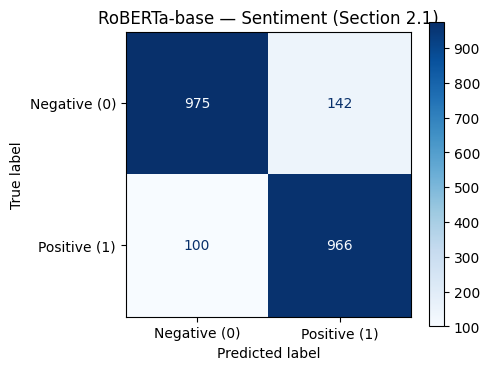

Saved confusion matrix.


In [37]:
# Confusion Matrix for best RoBERTa run
# Use run 2 (last run) swap to run 1 if it scores higher
cm = confusion_matrix(roberta_run2_labels, roberta_run2_preds)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm, display_labels=["Negative (0)", "Positive (1)"])
disp.plot(cmap="Blues", ax=ax)
ax.set_title("RoBERTa-base — Sentiment (Section 2.1)")
plt.tight_layout()
plt.savefig("cm_roberta_sentiment_21.png", dpi=150)
plt.show()
print("Saved confusion matrix.")


# Section 2.3  Monolingual vs Multilingual

 Compare RoBERTa-base (English only) against XLM-RoBERTa-base




In [38]:
# Run 1: XLM-RoBERTa-base, Seed=42
xlm_run1_report, xlm_run1_preds, xlm_run1_labels, xlm_model_run1, _ = train_and_evaluate(
    model_name="xlm-roberta-base",
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    task="Sentiment",
    seed=SEEDS[0],
    num_epochs=3,
)


 Model: xlm-roberta-base | Task: Sentiment | Seed: 42


Map:   0%|          | 0/3747 [00:00<?, ? examples/s]

Map:   0%|          | 0/313 [00:00<?, ? examples/s]

Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

              precision    recall  f1-score   support

 Sentiment=0       0.88      0.89      0.89      1117
 Sentiment=1       0.88      0.88      0.88      1066

    accuracy                           0.88      2183
   macro avg       0.88      0.88      0.88      2183
weighted avg       0.88      0.88      0.88      2183

Macro-F1: 0.8831


In [39]:
# Run 2: XLM-RoBERTa-base, Seed=1234
xlm_run2_report, xlm_run2_preds, xlm_run2_labels, xlm_model_run2, xlm_tokenizer = train_and_evaluate(
    model_name="xlm-roberta-base",
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    task="Sentiment",
    seed=SEEDS[1],
    num_epochs=3,
)


 Model: xlm-roberta-base | Task: Sentiment | Seed: 1234


Map:   0%|          | 0/3747 [00:00<?, ? examples/s]

Map:   0%|          | 0/313 [00:00<?, ? examples/s]

Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

              precision    recall  f1-score   support

 Sentiment=0       0.87      0.92      0.90      1117
 Sentiment=1       0.91      0.86      0.88      1066

    accuracy                           0.89      2183
   macro avg       0.89      0.89      0.89      2183
weighted avg       0.89      0.89      0.89      2183

Macro-F1: 0.8893


In [40]:
# Per-variety results
# Checking if XLM does better on Indian English

test_df_copy = test_df.copy().reset_index(drop=True)
test_df_copy["roberta_pred"] = roberta_run2_preds
test_df_copy["xlm_pred"] = xlm_run2_preds

print("\nPer-variety Macro-F1 — RoBERTa vs XLM-RoBERTa (Sentiment, Run 2):")
print(f"{'Variety':<10} {'RoBERTa Macro-F1':>20} {'XLM-RoBERTa Macro-F1':>22}")
print("-" * 55)

for variety in ["en-AU", "en-UK", "en-IN"]:
    mask = test_df_copy["variety"] == variety
    true = test_df_copy.loc[mask, "Sentiment"].astype(int).values
    rob = test_df_copy.loc[mask, "roberta_pred"].values
    xlm = test_df_copy.loc[mask, "xlm_pred"].values
    rob_f1 = f1_score(true, rob, average="macro")
    xlm_f1 = f1_score(true, xlm, average="macro")
    print(f"{variety:<10} {rob_f1:>20.4f} {xlm_f1:>22.4f}")




Per-variety Macro-F1 — RoBERTa vs XLM-RoBERTa (Sentiment, Run 2):
Variety        RoBERTa Macro-F1   XLM-RoBERTa Macro-F1
-------------------------------------------------------
en-AU                    0.8903                 0.8802
en-UK                    0.9456                 0.9428
en-IN                    0.8394                 0.8494


In [41]:
# Section 2.3 Summary Table
xlm_r1 = xlm_run1_report["macro avg"]
xlm_r2 = xlm_run2_report["macro avg"]
xlm_avg_f1 = (xlm_r1["f1-score"] + xlm_r2["f1-score"]) / 2

summary_23 = pd.DataFrame({
    "Model":     ["RoBERTa-base (Mono)", "RoBERTa-base (Mono)",
                  "XLM-RoBERTa (Multi)", "XLM-RoBERTa (Multi)"],
    "Run":       ["Run 1", "Run 2", "Run 1", "Run 2"],
    "Seed":      [SEEDS[0], SEEDS[1], SEEDS[0], SEEDS[1]],
    "Macro-F1":  [f"{r1['f1-score']:.4f}", f"{r2['f1-score']:.4f}",
                  f"{xlm_r1['f1-score']:.4f}", f"{xlm_r2['f1-score']:.4f}"],
    "Precision": [f"{r1['precision']:.4f}", f"{r2['precision']:.4f}",
                  f"{xlm_r1['precision']:.4f}", f"{xlm_r2['precision']:.4f}"],
    "Recall":    [f"{r1['recall']:.4f}", f"{r2['recall']:.4f}",
                  f"{xlm_r1['recall']:.4f}", f"{xlm_r2['recall']:.4f}"],
})
print("\nSection 2.3 Results (copy into report):")
print(summary_23.to_string(index=False))
print(f"\nRoBERTa avg Macro-F1:     {roberta_avg_f1:.4f}")
print(f"XLM-RoBERTa avg Macro-F1: {xlm_avg_f1:.4f}")


Section 2.3 Results (copy into report):
              Model   Run  Seed Macro-F1 Precision Recall
RoBERTa-base (Mono) Run 1    42   0.8896    0.8899 0.8900
RoBERTa-base (Mono) Run 2  1234   0.8891    0.8894 0.8895
XLM-RoBERTa (Multi) Run 1    42   0.8831    0.8832 0.8830
XLM-RoBERTa (Multi) Run 2  1234   0.8893    0.8913 0.8888

RoBERTa avg Macro-F1:     0.8894
XLM-RoBERTa avg Macro-F1: 0.8862


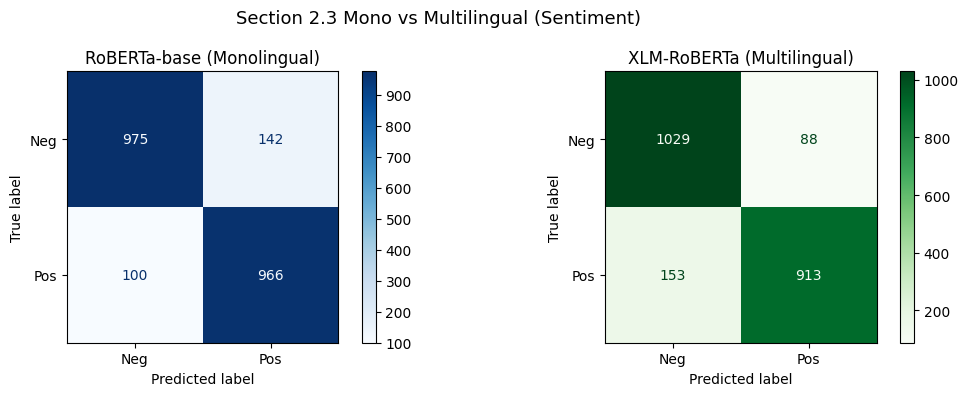

Saved side-by-side confusion matrices.


In [42]:
# Confusion Matrix for XLM-RoBERTa
cm_xlm = confusion_matrix(xlm_run2_labels, xlm_run2_preds)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(
    confusion_matrix(roberta_run2_labels, roberta_run2_preds),
    display_labels=["Neg", "Pos"]
).plot(cmap="Blues", ax=axes[0])
axes[0].set_title("RoBERTa-base (Monolingual)")

ConfusionMatrixDisplay(
    cm_xlm,
    display_labels=["Neg", "Pos"]
).plot(cmap="Greens", ax=axes[1])
axes[1].set_title("XLM-RoBERTa (Multilingual)")

plt.suptitle("Section 2.3 Mono vs Multilingual (Sentiment)", fontsize=13)
plt.tight_layout()
plt.savefig("cm_mono_vs_multi_23.png", dpi=150)
plt.show()

print("Saved side-by-side confusion matrices.")


## Visual Comparison All Experiments
Bar chart showing Macro-F1 across all models.

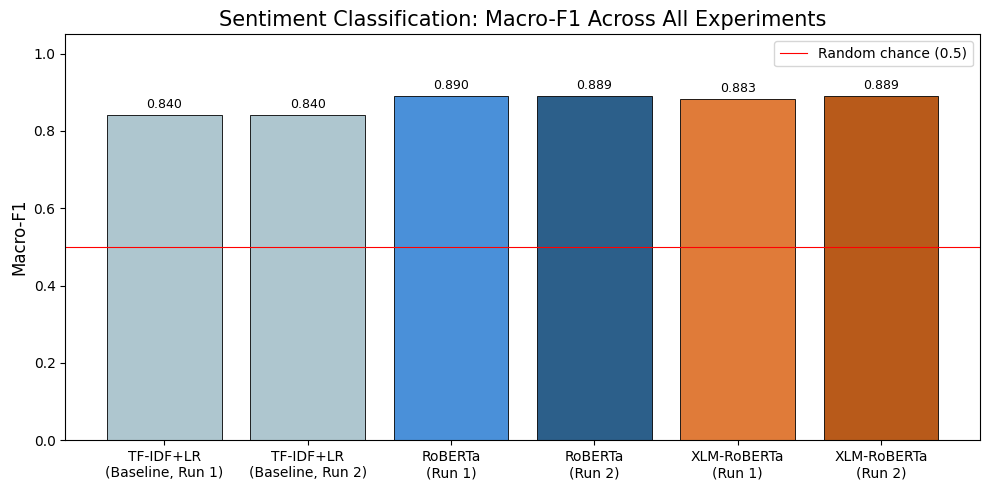

Saved comparison bar chart.


In [43]:
# TF-IDF + LR baseline: Macro-F1 = 0.84
models = [
    "TF-IDF+LR\n(Baseline, Run 1)",
    "TF-IDF+LR\n(Baseline, Run 2)",
    "RoBERTa\n(Run 1)",
    "RoBERTa\n(Run 2)",
    "XLM-RoBERTa\n(Run 1)",
    "XLM-RoBERTa\n(Run 2)",
]

f1_scores = [
    0.84, 0.84,
    r1["f1-score"],
    r2["f1-score"],
    xlm_r1["f1-score"],
    xlm_r2["f1-score"],
]

colours = ["#aec6cf", "#aec6cf", "#4a90d9", "#2c5f8a", "#e07b39", "#b85a1a"]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(models, f1_scores, color=colours, edgecolor="black", linewidth=0.6)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Macro-F1", fontsize=12)
ax.set_title("Sentiment Classification: Macro-F1 Across All Experiments", fontsize=15)

ax.axhline(0.5, color="red", linestyle="-", linewidth=0.8, label="Random chance (0.5)")
ax.legend()

plt.tight_layout()
plt.savefig("f1_comparison_all.png", dpi=150)
plt.show()

print("Saved comparison bar chart.")


## Save Best Model
Saving the best RoBERTa model



In [44]:
import os

# Save the better of the two RoBERTa runs
best_roberta_model = (
    roberta_model_run1 if r1["f1-score"] >= r2["f1-score"] else roberta_model_run2
)
best_run_label = "Run1" if r1["f1-score"] >= r2["f1-score"] else "Run2"
save_path = f"./best_roberta_sentiment_{best_run_label}"

best_roberta_model.save_pretrained(save_path)
roberta_tokenizer.save_pretrained(save_path)
print(f"Best RoBERTa model saved to: {save_path}")
print("Share this path with the team for Section 4 (LIME/SHAP) and Section 5 (Deployment).")
print("Do NOT include this folder in the ZIP submission.")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best RoBERTa model saved to: ./best_roberta_sentiment_Run1
Share this path with the team for Section 4 (LIME/SHAP) and Section 5 (Deployment).
Do NOT include this folder in the ZIP submission.
